In [1]:
# TP - Analyse de parties de flipper Dataviz

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Exercice 1

In [2]:
path = "../../data/flipper_games.csv"

In [3]:
games = pd.read_csv(path)
games.head()

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0


In [5]:
games.columns
games.info

<bound method DataFrame.info of                 timestamp player_id machine_id       machine_type arcade_zone  \
0     2026-02-03 10:00:00      P001        F17  electromechanical          C3   
1     2026-02-03 10:00:00      P221        F04        solid_state          D1   
2     2026-02-03 10:05:00      P034        F13            digital          C1   
3     2026-02-03 10:05:00      P007        F06        solid_state          D1   
4     2026-02-03 10:05:00      P009        F16  electromechanical          A2   
...                   ...       ...        ...                ...         ...   
5404  2026-02-12 21:20:00      P077        F11            digital          D1   
5405  2026-02-12 21:25:00      P180        F15  electromechanical          C2   
5406  2026-02-12 21:25:00      P228        F03        solid_state          A2   
5407  2026-02-12 21:25:00      P213        F01        solid_state          C3   
5408  2026-02-12 21:30:00      P004        F13            digital          A1

In [6]:
games["player_id"].nunique()

260

In [7]:
n_before = len(games)


Le dataset contient 5409 lignes et 14 colonnes

Exercice 2

In [8]:
#Supprimer les doublons 
games_clean = games.drop_duplicates()
games_clean

,timestamp,player_id,machine_id,machine_type,arcade_zone,game_mode,game_duration_s,pause_s,tilt_risk_pct,ball_speed_mps,playfield_temp_c,error_code,game_status,incident_label
0,2026-02-03 10:00:00,P001,F17,electromechanical,C3,speedrun,188,0,39.32,1.154,37.76,NaN,completed,0
1,2026-02-03 10:00:00,P221,F04,solid_state,D1,multiball,218,23,76.10,1.002,30.84,NaN,completed,0
2,2026-02-03 10:05:00,P034,F13,digital,C1,classic,143,21,5.86,0.965,33.96,NaN,completed,0
3,2026-02-03 10:05:00,P007,F06,solid_state,D1,multiball,319,41,47.16,1.054,28.43,NaN,completed,0
4,2026-02-03 10:05:00,P009,F16,electromechanical,A2,classic,175,33,60.06,0.934,22.61,NaN,completed,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5404,2026-02-12 21:20:00,P077,F11,digital,D1,classic,166,40,61.93,1.376,30.34,NaN,completed,0
5405,2026-02-12 21:25:00,P180,F15,electromechanical,C2,speedrun,168,21,66.50,1.109,31.17,NaN,completed,0
5406,2026-02-12 21:25:00,P228,F03,solid_state,A2,multiball,310,1,64.41,1.124,28.49,NaN,completed,0
5407,2026-02-12 21:25:00,P213,F01,solid_state,C3,speedrun,168,29,22.25,0.810,25.05,NaN,completed,0


In [9]:
games_clean = games_clean[games_clean["game_duration_s"] > 0]

In [10]:

games_clean = games_clean[games_clean["tilt_risk_pct"].between(0, 100)]
# games

In [11]:
games_clean = games_clean[games_clean["pause_s"] >= 0]

In [12]:
n_after = len(games_clean)
print(n_before, n_after)

5409 5354


Après le nettoyage, 55 lignes de données inutiles et incorrectes ont été supprimés. Le dataset est prêt à être représenté.

Exercice 3

In [13]:
games_clean["game_status"].value_counts(dropna=False)

game_status
completed    5076
failed        278
Name: count, dtype: int64

In [14]:
games_clean["is_error"] = (games_clean["game_status"] == "failed").astype(int)

games_clean[["game_status", "is_error"]].head(10)
games_clean["is_error"].value_counts()

is_error
0    5076
1     278
Name: count, dtype: int64

In [15]:
zone_kpi = games_clean.groupby("arcade_zone", as_index=False).agg(
    games_count=("player_id", "size"),
    unique_players=("player_id", "nunique"),
    error_rate=("is_error", "mean"),
    avg_pause_s=("pause_s", "mean"),
)

zone_kpi.head()

,arcade_zone,games_count,unique_players,error_rate,avg_pause_s
0,A1,650,238,0.046154,18.006154
1,A2,640,238,0.046875,18.081250
2,B1,700,248,0.045714,17.844286
3,B2,627,242,0.057416,17.496013
4,C1,709,243,0.045134,18.535966


In [16]:
zone_kpi = zone_kpi.sort_values("error_rate", ascending=False)
zone_kpi


,arcade_zone,games_count,unique_players,error_rate,avg_pause_s
5,C2,668,243,0.062874,18.485030
6,C3,686,241,0.059767,26.115160
3,B2,627,242,0.057416,17.496013
7,D1,674,244,0.051929,19.017804
1,A2,640,238,0.046875,18.081250
0,A1,650,238,0.046154,18.006154
2,B1,700,248,0.045714,17.844286
4,C1,709,243,0.045134,18.535966


Les taux d'erreur les plus élevées sont les zones C2, C3 et B2. Ca n'a pas l'air d'influer sur les autres paramètres.

Exercice 4

<Axes: xlabel='arcade_zone', ylabel='error_rate'>

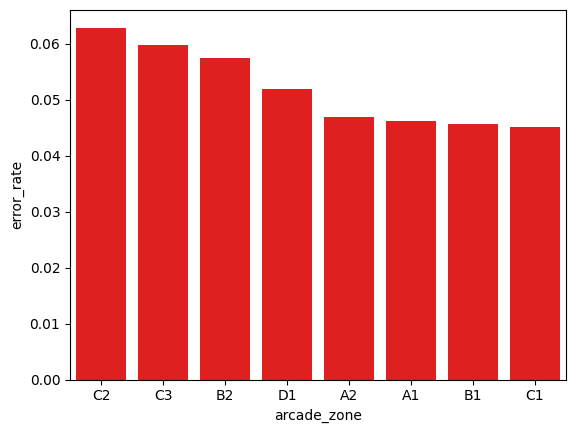

In [17]:
arcade_zone_err = zone_kpi.groupby("arcade_zone", as_index=False).agg(
    error_rate = ("error_rate", "mean")
).sort_values("error_rate", ascending = False)


sns.barplot(data=arcade_zone_err, x="arcade_zone", y="error_rate", color="red")

Nous avons le graphique du taux d'arreur par aracade_zone. On voit que la zone critique est C2, on pourrait savoir quelles machines correspondent à cela afin de faire leur maintenance.

Exercice 5

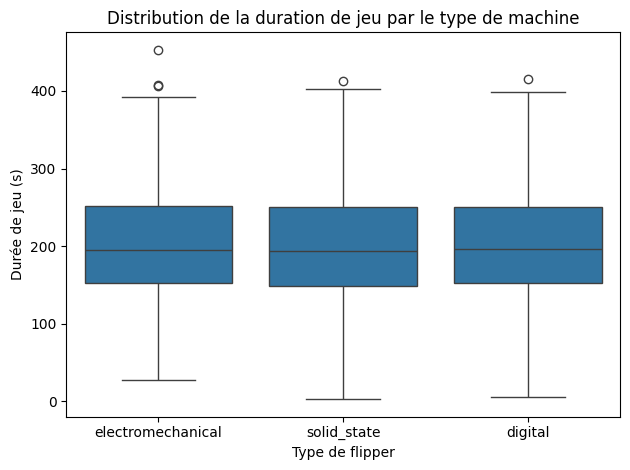

In [18]:
sns.boxplot(data=games_clean, x="machine_type", y="game_duration_s")
plt.title("Distribution de la duration de jeu par le type de machine")
plt.xlabel("Type de flipper")
plt.ylabel("Durée de jeu (s)")
plt.tight_layout()
plt.show()


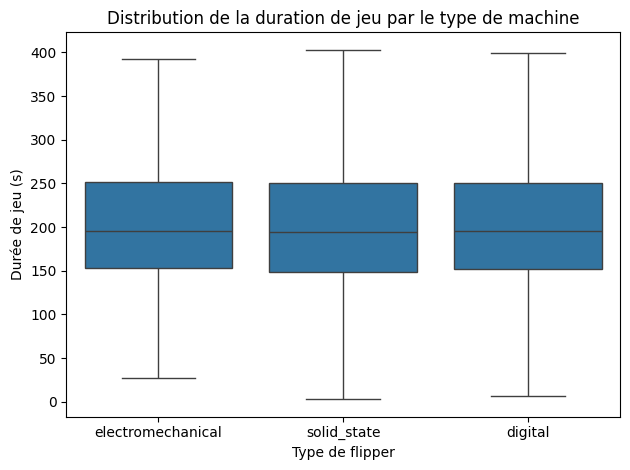

In [19]:
sns.boxplot(data=games_clean, x="machine_type", y="game_duration_s", showfliers=False)
plt.title("Distribution de la duration de jeu par le type de machine")
plt.xlabel("Type de flipper")
plt.ylabel("Durée de jeu (s)")
plt.tight_layout()
plt.show()


Les durées sont pareilles peu importe le type de machine. Donc le type de la machine, avec ou sans outliers, n'influe pas sur les durée de jeu, pour optimiser les performances.

Challenge final : Construire un score `risk_score` pour classer les machines de flipper les plus a risque:

In [26]:
machine_kpi = games_clean.groupby("machine_id", as_index=False).agg(
    games_count=("player_id","size"),
    error_rate=("is_error","mean"),
    avg_pause_s=("pause_s","mean"),
    avg_tilt_risk_pct=("tilt_risk_pct","mean"),
)
machine_kpi.head()

,machine_id,games_count,error_rate,avg_pause_s,avg_tilt_risk_pct
0,F01,253,0.035573,19.545455,56.367589
1,F02,292,0.075342,20.020548,53.014863
2,F03,266,0.048872,19.218045,55.742481
3,F04,264,0.053030,20.200758,54.698939
4,F05,254,0.059055,18.870079,55.696378


In [35]:
machine_kpi_30 = machine_kpi[machine_kpi["games_count"] >= 30]


In [36]:

df = machine_kpi_30  

df["pause_norm"] = (df["avg_pause_s"] - df["avg_pause_s"].min()) / (df["avg_pause_s"].max() - df["avg_pause_s"].min())

df["tilt_risk_norm"] = (df["avg_tilt_risk_pct"] - df["avg_tilt_risk_pct"].min()) / (df["avg_tilt_risk_pct"].max() - df["avg_tilt_risk_pct"].min())

df[["avg_pause_s", "pause_norm", "avg_tilt_risk_pct", "tilt_risk_norm"]].head()

,avg_pause_s,pause_norm,avg_tilt_risk_pct,tilt_risk_norm
0,19.545455,0.706563,56.367589,0.765198
1,20.020548,0.839838,53.014863,0.048839
2,19.218045,0.614717,55.742481,0.631635
3,20.200758,0.890391,54.698939,0.408667
4,18.870079,0.517105,55.696378,0.621784


In [39]:
cols = ["machine_id", "games_count", "error_rate", "avg_pause_s", "pause_norm",
        "avg_tilt_risk_pct", "tilt_risk_norm", "risk_score"]

top5 = machine_kpi_30.sort_values("risk_score", ascending=False).head(5)
top5[cols]

,machine_id,games_count,error_rate,avg_pause_s,pause_norm,avg_tilt_risk_pct,tilt_risk_norm,risk_score
9,F10,264,0.087121,19.113636,0.585428,57.466515,1.000000,0.419189
6,F07,254,0.074803,20.059055,0.850640,55.482323,0.576048,0.407803
19,F20,235,0.034043,20.591489,1.000000,54.621277,0.392073,0.395436
0,F01,253,0.035573,19.545455,0.706563,56.367589,0.765198,0.382795
3,F04,264,0.053030,20.200758,0.890391,54.698939,0.408667,0.375366


Ce sont les 5 machines les plus à risques. La F10 par exemple l'est le plus à cause du tilt moyen le plus élevé ainsi que son taux d'erreur à 8.7%. On voit que la pause influence aussi le score de risque.
On devrait cibler F10 en premier pour contrôler son tilt et faire plus de maintenance pour abaisser son taux d'erreur.
Et pour les autres on pourrait surveiller et agir sur la pause moyenne.

Compte-rendu

Pour conclure ce TP, reprenons ce qu'on a fait depuis le début.
On a fait un contrôle du dataset pour avoir sa structure, les types, le volume. Ensuite, on a nettoyé le dataset pour optimiser et éviter d'avoir des données incohérentes.
On a identifié la zone C2 très critique et on a représenté pour avoir un diagnostic global visible. 
A l'aide du boxplot, on sait que le type de machine n'est pas la raison du problème de performance (durée de jeu).
Les machines les plus à risque sont F01, F04, F03, F05, F02 (score ≈ 0.30–0.38).
Il faut agir sur ces machines en priorité en mettant en place des maintenances, réparations.
